![image.png](https://i.imgur.com/a3uAqnb.png)

# Natural Language Processing (NLP) 
## Third : Word embeddings

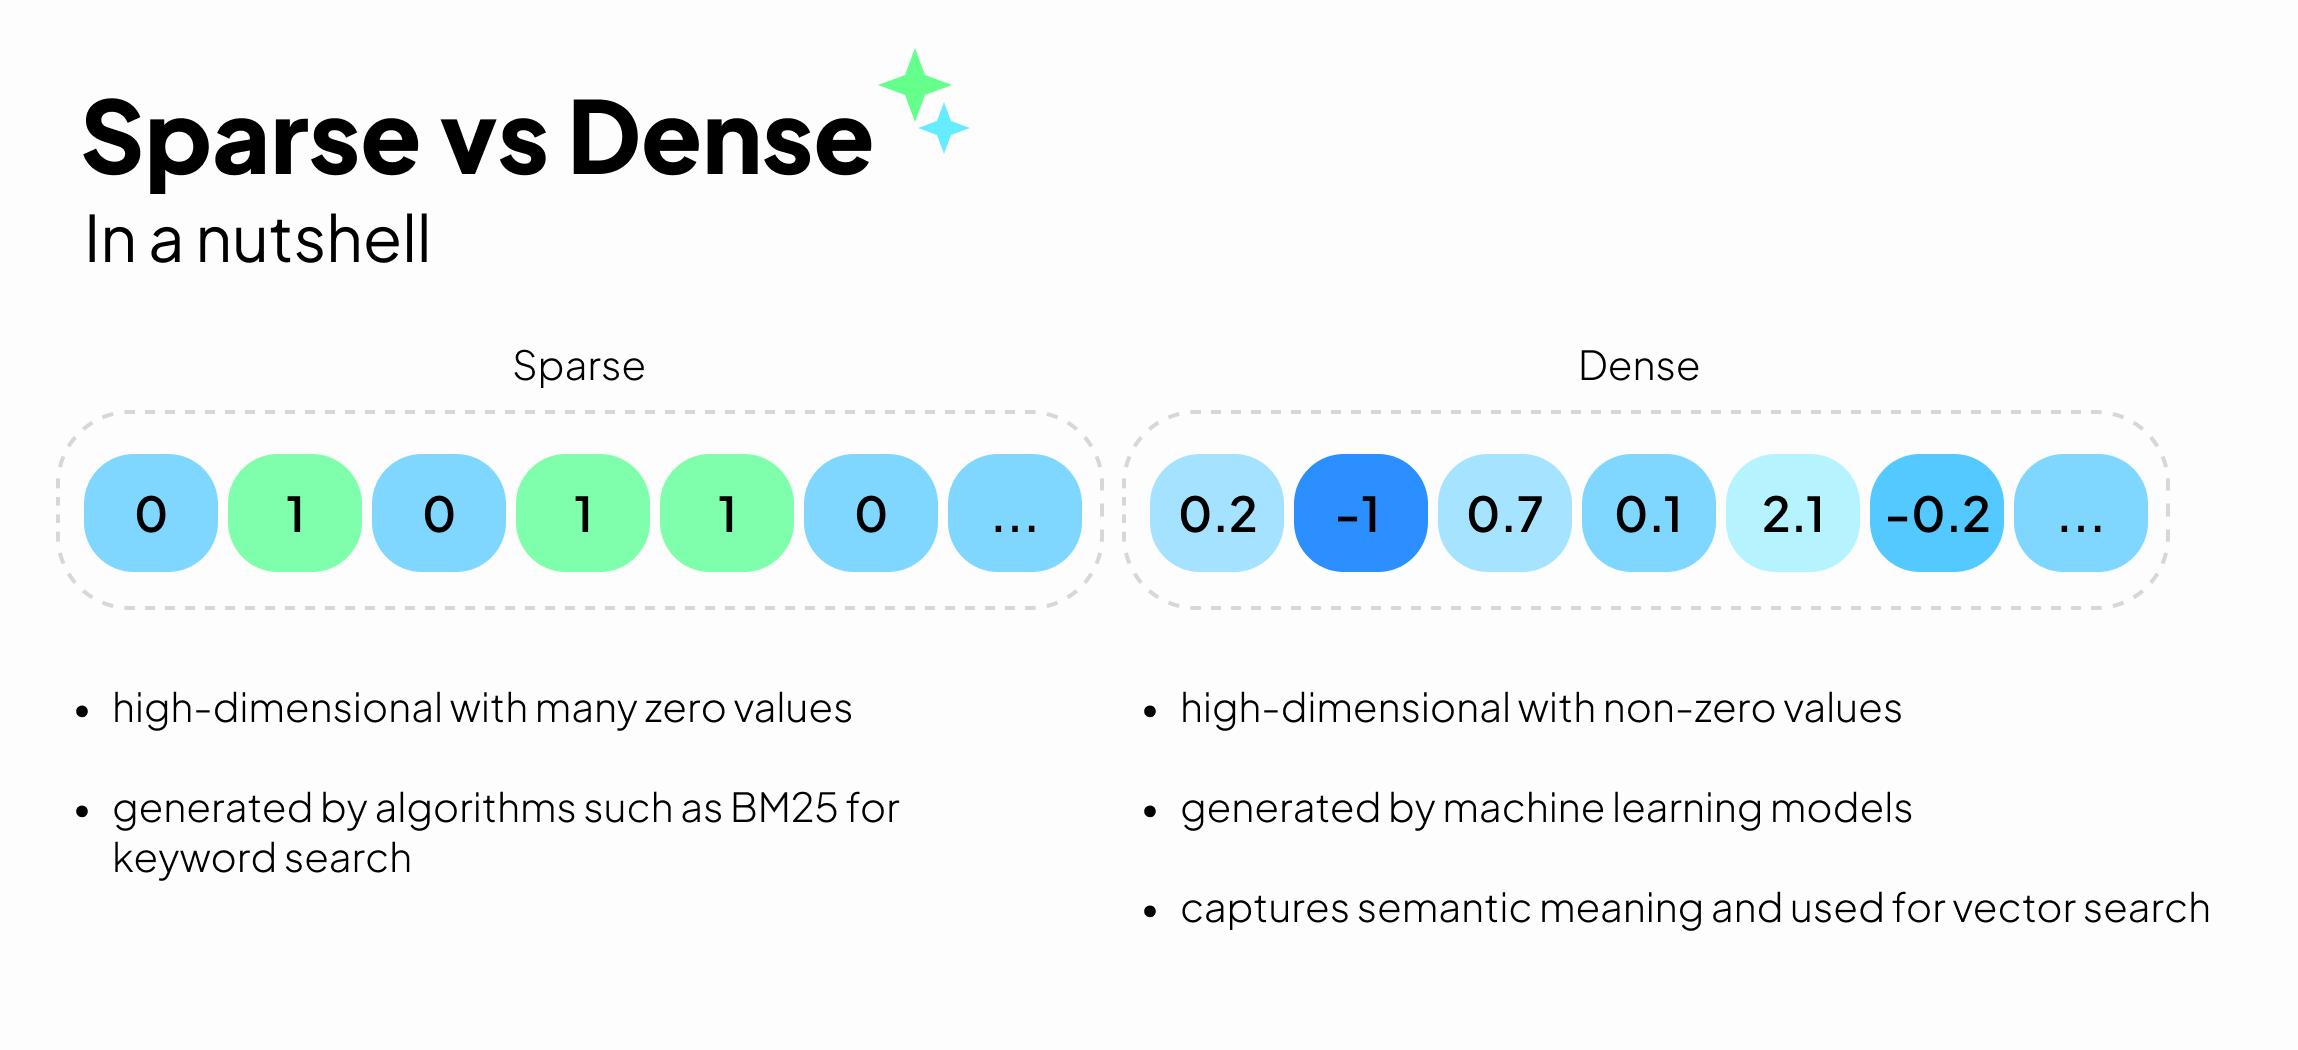
###  What are Sparse Vectors?

- **Sparse vectors** are vectors where **most of the values are zero**.
- This is what happens in models like:
  - **Bag of Words (BoW)**
  - **TF-IDF**
- The length of the vector equals the size of the **entire vocabulary** (which can be tens of thousands of words).
- Only the positions corresponding to the words in the document have non-zero values.

 Example (Sparse BoW Vector):

| Word         | apple | love | machine | learning | AI  | ... | zebra |
|-------------|-------|------|---------|----------|-----|-----|-------|
| Document 1  | 1     | 1    | 1       | 1        | 0   | ... | 0     |





###  What are Dense Vectors?

- **Dense vectors** have **no zeros (or very few zeros)**—every element carries some numerical value.
- These are used in:
  - **Word2Vec**
  - **GloVe**
  - **FastText**
- Each word is represented as a **fixed-length dense vector** (e.g., 100 or 300 dimensions) regardless of vocabulary size.

 Example (Dense Word Embedding Vector):

| Dimension 1 | Dimension 2 | Dimension 3 | ... | Dimension 100 |
|------------|-------------|-------------|-----|---------------|
| 0.25       | -0.17       | 0.03        | ... | 0.41          |








## 2- Word2Vec 

Each word is represented as a vector:

$$
w \in \mathbb{R}^{d}
$$

where:

- $w$ is the word vector.
- $d$ is the embedding dimension.

The **Skip-Gram** model learns word embeddings by maximizing the probability of observing context words given a target word:

$$
P(w_c \mid w_t)=
\frac{\exp\left(v_{w_c}^{T}v_{w_t}\right)}
{\sum_{w \in V}\exp\left(v_{w}^{T}v_{w_t}\right)}
$$

where:

- $w_t$ is the target word.
- $w_c$ is a context word.
- $V$ is the vocabulary.
- $v_{w_t}$ and $v_{w_c}$ are the learned word vectors.

To measure how similar two words are, Word2Vec typically uses **cosine similarity**:

$$
\text{Cosine Similarity}(a,b)=
\frac{a \cdot b}{\|a\|\|b\|}
$$

- A value close to **1** means the words are very similar.
- A value close to **0** means they are unrelated.
- A value close to **-1** means they are opposite.

In [39]:
!pip install gensim


[notice] A new release of pip is available: 26.1.1 -> 26.2
[notice] To update, run: pip install --upgrade pip


In [40]:
import gensim.downloader as api

# Load pre-trained Word2Vec embeddings
word2vec = api.load("word2vec-google-news-300")

words = [
    "royal", "queen", "king",
    "vehicle", "bus", "car",
    "animal", "dog", "cat",
    "woman", "man"
]

for word in words:
    print(f"{word} -> {word2vec[word][:5]}")

print(
    "\nSimilarity between king and queen:",
    word2vec.similarity("king", "queen")
)

royal -> [-0.03564453  0.0559082  -0.34570312  0.04199219 -0.20410156]
queen -> [ 0.00524902 -0.14355469 -0.06933594  0.12353516  0.13183594]
king -> [ 0.12597656  0.02978516  0.00860596  0.13964844 -0.02563477]
vehicle -> [ 0.33789062 -0.05249023  0.08496094 -0.18847656 -0.05688477]
bus -> [ 0.05932617 -0.16992188  0.03881836 -0.04956055  0.03833008]
car -> [ 0.13085938  0.00842285  0.03344727 -0.05883789  0.04003906]
animal -> [ 0.00811768  0.20507812 -0.16992188  0.11816406 -0.11572266]
dog -> [ 0.05126953 -0.02233887 -0.17285156  0.16113281 -0.08447266]
cat -> [ 0.0123291   0.20410156 -0.28515625  0.21679688  0.11816406]
woman -> [ 0.24316406 -0.07714844 -0.10302734 -0.10742188  0.11816406]
man -> [ 0.32617188  0.13085938  0.03466797 -0.08300781  0.08984375]

Similarity between king and queen: 0.6510957


# 2. GloVe Word Embeddings

## What is GloVe?

**GloVe (Global Vectors for Word Representation)** is an unsupervised learning algorithm for learning **word embeddings** from **global word co-occurrence statistics**.

A limitation of **Word2Vec** is that it learns mainly from **local context windows** and does not explicitly use the global co-occurrence statistics of the entire corpus. GloVe addresses this by analyzing how often words appear together across the whole dataset.



### Co-occurrence Matrix

GloVe first builds a **co-occurrence matrix**.

Let $X$ be the co-occurrence matrix, where:

* $X_{ij}$ is the number of times word $j$ appears in the context of word $i$.
* The context is typically defined using a fixed-size window around the target word.

The total co-occurrences for word $i$ are:

$$
X_i = \sum_k X_{ik}
$$



> I like deep learning
> I like NLP
> I enjoy flying



```text
I, like, deep, learning, NLP, enjoy, flying
```

Assume a **context window of 1**.

| Target Word | Context Words     |
| ----------- | ----------------- |
| I           | like, like, enjoy |
| like        | I, deep, I, NLP   |
| deep        | like, learning    |
| learning    | deep              |
| NLP         | like              |
| enjoy       | I, flying         |
| flying      | enjoy             |

### Co-occurrence Matrix

|              |  I | like | deep | learning | NLP | enjoy | flying |
| ------------ | -: | ---: | ---: | -------: | --: | ----: | -----: |
| **I**        |  0 |    2 |    0 |        0 |   0 |     1 |      0 |
| **like**     |  2 |    0 |    1 |        0 |   1 |     0 |      0 |
| **deep**     |  0 |    1 |    0 |        1 |   0 |     0 |      0 |
| **learning** |  0 |    0 |    1 |        0 |   0 |     0 |      0 |
| **NLP**      |  0 |    1 |    0 |        0 |   0 |     0 |      0 |
| **enjoy**    |  1 |    0 |    0 |        0 |   0 |     0 |      1 |
| **flying**   |  0 |    0 |    0 |        0 |   0 |     1 |      0 |



### GloVe Objective Function

GloVe learns word vectors by minimizing:

$$
J = \sum_{i,j=1}^{V} f(X_{ij}) \left( w_i^T \tilde{w}_j + b_i + \tilde{b}*j - \log X*{ij} \right)^2
$$

The model tries to make:

$$
w_i^T \tilde{w}*j \approx \log X*{ij}
$$

where:

| Symbol        | Meaning             |
| ------------- | ------------------- |
| $V$           | Vocabulary size     |
| $w_i$         | Target word vector  |
| $\tilde{w}_j$ | Context word vector |
| $b_i$         | Target bias         |
| $\tilde{b}_j$ | Context bias        |
| $f(X_{ij})$   | Weighting function  |



### Weighting Function

To reduce the influence of very rare and very frequent word pairs, GloVe uses:

$$
f(X_{ij})=
\begin{cases}
\left(\dfrac{X_{ij}}{X_{\max}}\right)^\alpha, & X_{ij}<X_{\max} \
1, & \text{otherwise}
\end{cases}
$$

where:

* $X_{\max}$ is a threshold.
* $\alpha$ is typically **0.75**.



###  Training

During training, GloVe updates:

* Target vectors $w_i$
* Context vectors $\tilde{w}_j$
* Biases $b_i$ and $\tilde{b}_j$

using gradient descent to minimize the objective function.



### Final Word Embeddings

Each word learns two vectors:

* Target vector: $w_i$
* Context vector: $\tilde{w}_i$

The final embedding is:

$$
v_i = w_i + \tilde{w}_i
$$


In [41]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from gensim.test.utils import datapath, get_tmpfile
from gensim.models import KeyedVectors
from gensim.scripts.glove2word2vec import glove2word2vec
import gensim.downloader as api

In [ ]:
model = api.load('glove-wiki-gigaword-100')  

In [ ]:
print(model['bread'])  

[-0.66146    0.94335   -0.72214    0.17403   -0.42524    0.36303
  1.0135    -0.14802    0.25817   -0.20326   -0.64338    0.16632
  0.61518    1.397     -0.094506   0.0041843 -0.18976   -0.55421
 -0.39371   -0.22501   -0.34643    0.32076    0.34395   -0.7034
  0.23932    0.69951   -0.16461   -0.31819   -0.34034   -0.44906
 -0.069667   0.35348    0.17498   -0.95057   -0.2209     1.0647
  0.23231    0.32569    0.47662   -1.1206     0.28168   -0.75172
 -0.54654   -0.66337    0.34804   -0.69058   -0.77092   -0.40167
 -0.069351  -0.049238  -0.39351    0.16735   -0.14512    1.0083
 -1.0608    -0.87314   -0.29339    0.68278    0.61634   -0.088844
  0.88094    0.099809  -0.27161   -0.58026    0.50364   -0.93814
  0.67576   -0.43124   -0.10517   -1.2404    -0.74353    0.28637
  0.29012    0.89377    0.67406    0.86422   -0.30693   -0.14718
  0.078353   0.74013    0.32658   -0.052579  -1.1665     0.87079
 -0.69402   -0.75977   -0.37164   -0.11887    0.18551    0.041883
  0.59352    0.30519   -0.

In [44]:
print(model['croissant'])  

[-0.25144    0.52157   -0.75452    0.28039   -0.31388    0.274
  1.1971    -0.10519    0.82544   -0.33398   -0.21417    0.22216
  0.14982    0.47384    0.41984    0.69397   -0.25999   -0.44414
  0.58296   -0.30851   -0.076455   0.33468    0.28055   -0.99012
  0.30349    0.39128    0.031526  -0.095395  -0.004745  -0.81347
  0.27869   -0.1812     0.14632   -0.42186    0.13857    1.139
  0.14925   -0.051459   0.37875   -0.2613     0.011081  -0.28881
 -0.38662   -0.3135    -0.1954     0.19248   -0.52995   -0.40674
 -0.25159    0.06272   -0.32724    0.28374   -0.2155    -0.061832
 -0.50134    0.0093959  0.30715    0.3873    -0.74554   -0.45947
  0.40032   -0.1378    -0.26968   -0.3946    -0.64876   -0.47149
 -0.085536   0.092795  -0.034018  -0.61906    0.19123    0.20563
  0.29056   -0.010908   0.15313    0.33144    0.33806    0.061708
  0.20785    0.65348   -0.053222   0.18589    0.32647   -0.11923
  0.42008   -0.26931    0.025489   0.0036535  0.1327    -0.22763
  0.07564    0.55773    0.2


## 3-Similarity Between GloVe Vectors



GloVe represents each word as a numerical vector.

Words with similar meanings usually have vectors that are close to each other.

Similarity is measured using cosine similarity:

$$
\text{cosine similarity}(a,b)


\frac{a \cdot b}
{|a||b|}
$$

A value close to $1$ means the word vectors are highly similar.


In [45]:
model.most_similar('banana')

[('coconut', 0.7097253203392029),
 ('mango', 0.7054824829101562),
 ('bananas', 0.6887733340263367),
 ('potato', 0.6629636287689209),
 ('pineapple', 0.6534532308578491),
 ('fruit', 0.6519854664802551),
 ('peanut', 0.6420575976371765),
 ('pecan', 0.6349173188209534),
 ('cashew', 0.6294420957565308),
 ('papaya', 0.6246591210365295)]

In [46]:
model.most_similar(negative='banana')

[('shunichi', 0.49618104100227356),
 ('ieronymos', 0.4736502170562744),
 ('pengrowth', 0.4668096601963043),
 ('höss', 0.4636845588684082),
 ('damaskinos', 0.4617849290370941),
 ('yadin', 0.4617374837398529),
 ('hundertwasser', 0.4588957726955414),
 ('ncpa', 0.4577339291572571),
 ('maccormac', 0.4566109776496887),
 ('rothfeld', 0.4523947238922119)]

In [47]:

result = model.most_similar(positive=['woman', 'king'], negative=['man'])  
print("{}: {:.4f}".format(*result[0]))  

queen: 0.7699


In [48]:
def analogy(x1, x2, y1):
    result = model.most_similar(positive=[y1, x2], negative=[x1])  # Perform analogy based on provided words
    return result[0][0] 

In [49]:
analogy('pencil', 'sketching', 'camera')

'photographing'

In [50]:
analogy('japan', 'japanese', 'australia')

'australian'

In [51]:
analogy('obama', 'clinton', 'reagan')

'nixon'

In [52]:
analogy('tall', 'tallest', 'long')

'longest'

In [53]:
analogy('good', 'fantastic', 'bad')

'terrible'


## 4-Finding the Odd Word Out
The `doesnt_match()` function finds the word whose GloVe vector is least similar to the others.





Given a set of word vectors:

$$
\{ \vec{v}_1, \vec{v}_2, \ldots, \vec{v}_n \}
$$

First, the model computes the mean vector:

$$
\vec{v}_{\text{mean}}
=
\frac{1}{n}
\sum_{i=1}^{n}
\vec{v}_i
$$

Then, it computes the cosine similarity between each word vector and the mean vector:

$$
\text{cosine similarity}
\left(
\vec{v}_i,
\vec{v}_{\text{mean}}
\right)
=
\frac{
\vec{v}_i \cdot \vec{v}_{\text{mean}}
}{
\|\vec{v}_i\|
\|\vec{v}_{\text{mean}}\|
}
$$

The word with the lowest cosine similarity is identified as the odd one out.

In [54]:
# Word out of context
print(model.doesnt_match("breakfast cereal dinner lunch".split()))  # Find the word that doesn't fit the context

cereal


In [55]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def display_pca_scatterplot(model, words):
    vectors = [model[word] for word in words]
    points = PCA(n_components=2).fit_transform(vectors)

    plt.figure(figsize=(14, 10))
    plt.scatter(points[:, 0], points[:, 1])

    for word, (x, y) in zip(words, points):
        plt.text(x, y, word, fontsize=11)

    plt.title("GloVe Word Embeddings")
    plt.grid()
    plt.show()

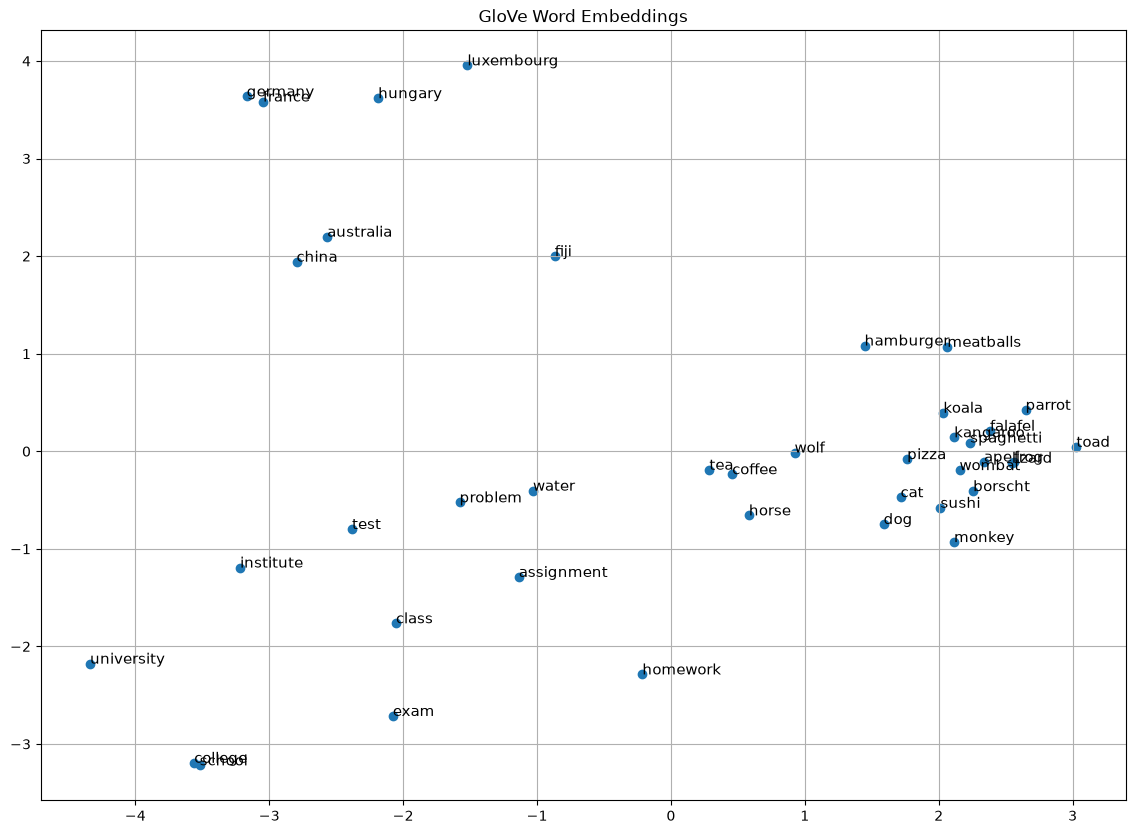

In [56]:
display_pca_scatterplot(
    model,
    [
        "coffee", "tea", "water",
        "spaghetti", "borscht", "hamburger", "pizza", "falafel", "sushi", "meatballs",
        "dog", "horse", "cat", "monkey", "parrot", "koala", "lizard",
        "frog", "toad", "ape", "kangaroo", "wombat", "wolf",
        "france", "germany", "hungary", "luxembourg", "australia", "fiji", "china",
        "homework", "assignment", "problem", "exam", "test", "class",
        "school", "college", "university", "institute"
    ]
)

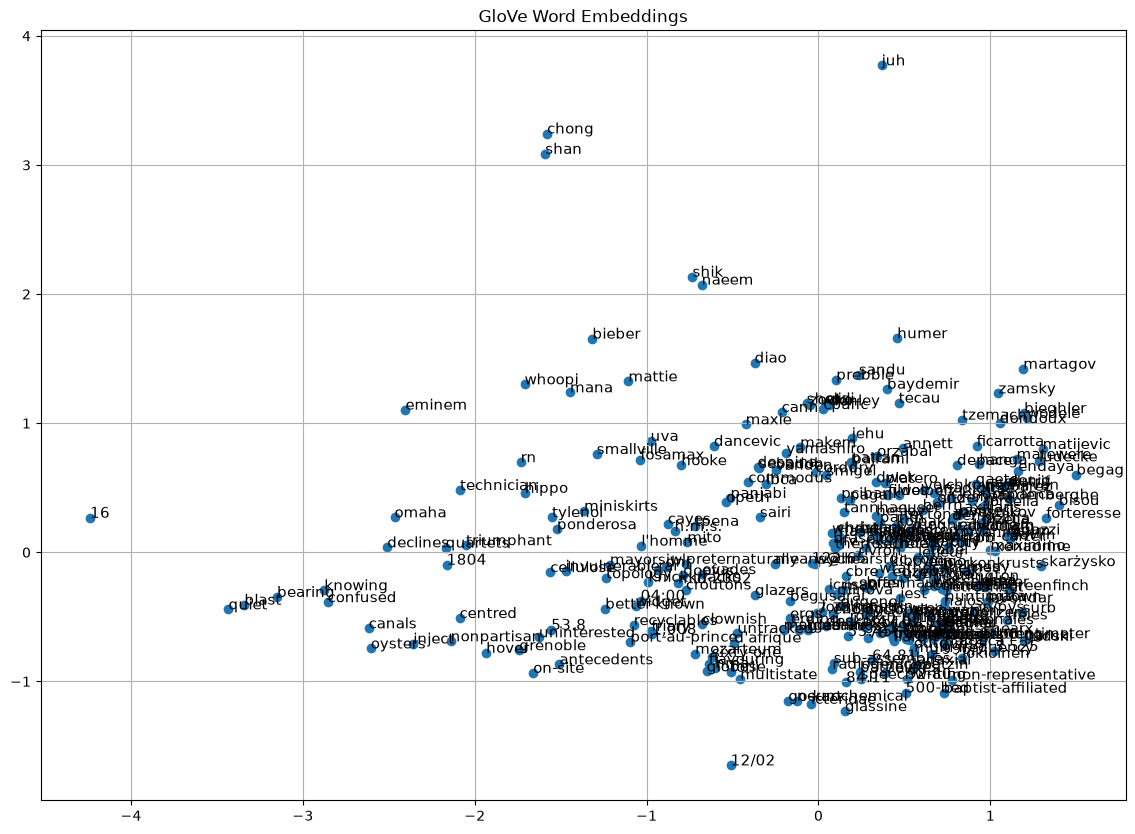

In [57]:
display_pca_scatterplot(model, words=np.random.choice(model.index_to_key, 300, replace=False))

### Exercise: Exploring Word Similarities with GloVe

Use a pre-trained GloVe model to explore semantic similarities between words.


1. Load the pre-trained GloVe embeddings.
2. Find the **top 5 most similar words** for each of the following:
   - `apple`
   - `computer`
   - `university`
3. Display the similar words and their similarity scores.

apple [('microsoft', 0.7449405193328857), ('ibm', 0.6821643114089966), ('intel', 0.6778088212013245), ('software', 0.6775422692298889), ('dell', 0.6741442680358887)]
computer [('computers', 0.8751984238624573), ('software', 0.8373122215270996), ('technology', 0.7642159461975098), ('pc', 0.7366448640823364), ('hardware', 0.7290390729904175)]
university [('college', 0.8294212818145752), ('harvard', 0.8156033754348755), ('yale', 0.8113803267478943), ('professor', 0.8103784918785095), ('graduate', 0.7993000745773315)]


### Exercise: Word Analogies with GloVe

Use the GloVe model to complete these analogies:

1. `architect : building :: composer : ?`
2. `thermometer : temperature :: barometer : ?`
3. `democracy : election :: monarchy : ?`

architect : building :: composer : music
thermometer : temperature :: barometer : indicator
democracy : election :: monarchy : elections


### Exercise: Finding the Word That Does Not Belong

Use the GloVe model’s `doesnt_match()` function to find the word that does not belong in each group.

1. `["red", "blue", "green", "apple"]`
2. `["cat", "dog", "fish", "car"]`
3. `["breakfast", "lunch", "dinner", "banana"]`

['red', 'blue', 'green', 'apple'] -> apple
['cat', 'dog', 'fish', 'car'] -> car
['breakfast', 'lunch', 'dinner', 'banana'] -> banana


### Exercise: Visualizing Word Vectors with PCA

Use PCA to reduce GloVe word vectors to two dimensions and visualize them.

Use these words:

- `king`, `queen`, `man`, `woman`, `prince`, `princess`
- `car`, `bicycle`, `airplane`, `train`, `boat`
- `dog`, `cat`, `fish`, `bird`, `hamster`

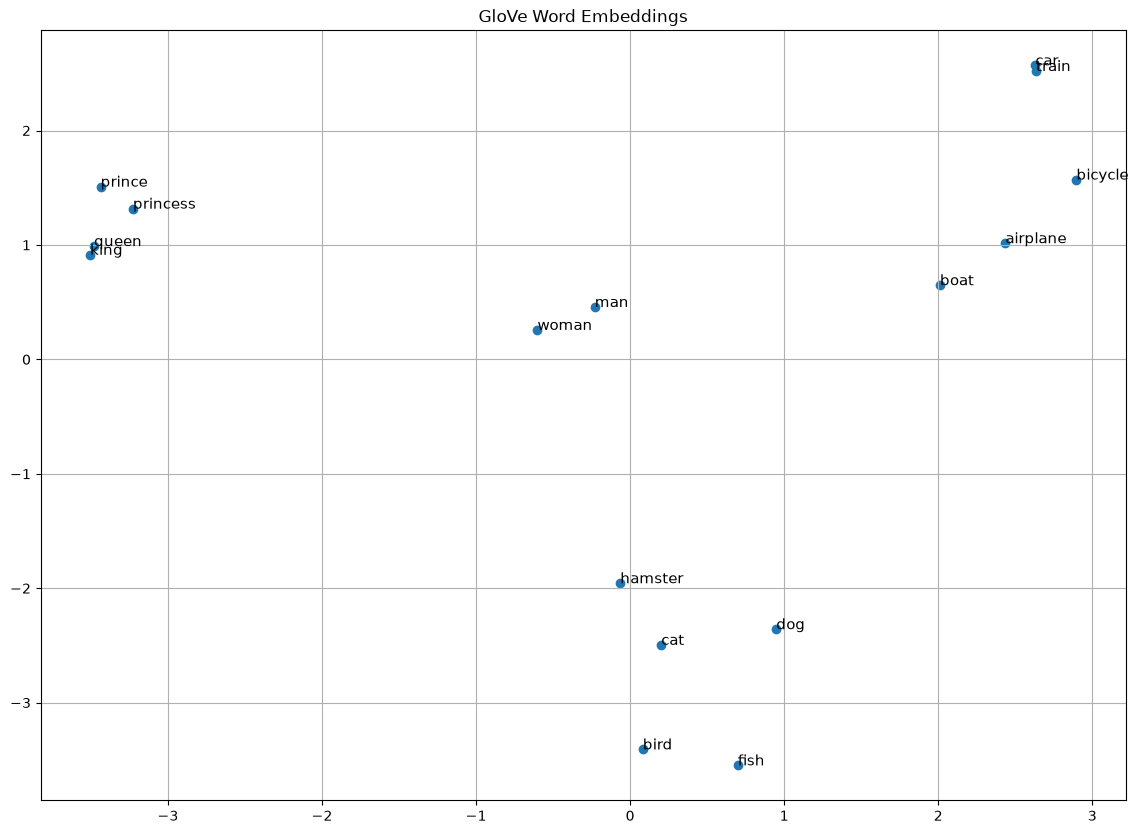

### Contributed by : Lama Ayash